# Day 2 — PyTorch: Building Neural Networks

## Note 2.4 — From Notebook to Project

> **Purpose of this note:** turn the exploratory work from Notes 2.1–2.3 into a small, reproducible machine-learning project.

This note is written to be read from top to bottom without a separate guide. Whenever a technical term appears, the note explains what it means, why it matters, and how it appears in the code.

### Learning goal and outcome

**Goal.** Turn the work of Notes 2.1–2.3 into a project another person can **clone, install, run, test, inspect, and reproduce** — without opening the training notebook.

**In plain English:** a notebook is where we explored the model; this project is where we package the model so that another person can run the same workflow using a command such as:

```bash
python -m src.training.train --config configs/baseline.yaml
```

**Outcome.** By the end of this note, the generated repository contains reusable Python modules, configuration files, tests, dependency instructions, a README, and Git rules. It also produces a saved model checkpoint and a JSON record describing the run.

### Objectives

By the end of this note you should be able to:

- explain why a notebook is excellent for exploration but weak as the main software deliverable;
- create an isolated Python environment and understand why dependencies must be recorded;
- explain the difference between a **direct dependency** (a package your project explicitly needs) and a **transitive dependency** (a package pulled in by another package);
- extract data, model, training, evaluation, and inference code into importable modules under `src/`;
- move run-specific values such as learning rate and hidden-layer sizes into YAML configuration files;
- seed the random-number generators used by the project and understand that seeding is not a guarantee of bit-for-bit identity on every platform;
- run training from a terminal and save the resulting model and experiment record;
- write fast tests that catch shape and interface mistakes without training a neural network;
- use `.gitignore` so generated data/checkpoints do not accidentally become source-controlled files;
- structure commits and a README so another person can understand the project without asking the author.

### Dataset used

**UCI Bank Marketing**, the same dataset used in Notes 2.2 and 2.3. This note is primarily about **software structure**, not new dataset analysis. The dataset is simply the real input that lets us prove the extracted pipeline works.

The data module downloads the dataset when necessary, caches it locally, removes the known target-leaking `duration` feature, performs the train/validation/test split, encodes categorical features, standardizes numeric features using training data only, and returns arrays suitable for PyTorch.

### Table of contents

0. [Quick glossary](#glossary)
1. [Why the notebook is not the deliverable](#s1)
2. [Environments that reproduce](#s2)
3. [Extracting the notebook into modules](#s3)
4. [Configuration and seeds](#s4)
5. [Training from the command line](#s5)
6. [Git a reviewer can understand](#s6)
7. [Conclusion](#s7)

### How this note works — and an important limitation

This notebook **creates a real project on disk**. Cells containing `%%writefile` write actual Python/config/text files into `bank_marketing_project/`, and later cells execute those files.

**If you are on Colab or Kaggle, the runtime filesystem can disappear when the session ends.** The notebook therefore creates a ZIP archive near the end. Download that archive before closing the session if you are not working on a persistent local machine.

### How to read the code

For every important module, read in this order:

1. **What is this file responsible for?**
2. **What goes into it?**
3. **What comes out?**
4. **Which assumptions must stay true?**
5. **Which test or configuration protects that assumption?**

That habit is the main engineering skill this note is teaching.

### Runtime budget

| Section | Approximate time |
|---|---|
| Sections 1–4 — writing files | under 5 s total |
| Section 5 — the command-line training run | ~30 s (plus download on a cold start) |
| Section 6 — git operations | under 5 s |

Total is roughly **one minute**, most of it the training run.

In [1]:
import os
import sys
import json
import shutil
import subprocess
from pathlib import Path

print(f"python : {sys.version.split()[0]}")
print(f"cwd    : {Path.cwd()}")

# Everything this note creates lives under one directory.
PROJECT = Path("bank_marketing_project")
print(f"\nThis note will create: {PROJECT.resolve()}")

python : 3.13.9
cwd    : /Users/solomonpromise/Documents/Simplilearn Classes/Deep Learning/Day 2

This note will create: /Users/solomonpromise/Documents/Simplilearn Classes/Deep Learning/Day 2/bank_marketing_project


<a id="glossary"></a>
## Quick glossary before we start

| Term | Plain-English meaning |
|---|---|
| **Notebook** | Interactive document containing code, prose, and outputs. |
| **Module** | A reusable Python file, usually a `.py` file. |
| **Package** | A collection of Python modules that can be imported together. |
| **Dependency** | Software the project needs in order to run. |
| **Configuration** | Settings that define a particular run without changing the algorithm. |
| **Checkpoint** | A saved model/training state. |
| **Inference** | Using a trained model to produce predictions. |
| **Unit test** | A small automated check of one software contract. |
| **Reproducibility** | Making the conditions and procedure of a run explicit enough to recreate and understand it. |
| **Target leakage** | Giving the model information that would not be available when the real prediction is made. |

<a id="s1"></a>
## 1. Why the notebook is not the deliverable

A notebook is a sequence of cells, but **the order in which cells are displayed is not the same thing as the order in which they were executed**. You can run cell 8 before cell 3, change a variable, and leave outputs from an earlier state visible.

### Hidden state

**Hidden state** means that the result of a cell depends on information created or changed somewhere else in the session. The following tiny example demonstrates the problem.

The function below does not store its threshold inside the function. It reads the global variable `threshold`. If another cell changes that variable, the same function call can return a different answer.

**Plain-English lesson:** a saved notebook does not automatically tell a reviewer which sequence of state changes produced its visible outputs.

In [2]:
# A concrete demonstration of hidden state, in miniature.
threshold = 0.5

def classify(p):
    return "yes" if p >= threshold else "no"       # closes over a global

print(f"classify(0.6) with threshold={threshold} -> {classify(0.6)}")

threshold = 0.9      # imagine this is a cell you ran, then scrolled past
print(f"classify(0.6) with threshold={threshold} -> {classify(0.6)}")
print()
print("The function's behaviour changed without the function changing.")
print("Re-run the cells in a different order and you get a different answer.")
print("Nothing in the notebook records which order produced your saved output.")

classify(0.6) with threshold=0.5 -> yes
classify(0.6) with threshold=0.9 -> no

The function's behaviour changed without the function changing.
Re-run the cells in a different order and you get a different answer.
Nothing in the notebook records which order produced your saved output.


### Read the demonstration step by step

- `threshold = 0.5` creates state outside the function.
- `classify()` reads that outside state.
- The first call therefore uses `0.5` and returns `yes` for `0.6`.
- The notebook then changes `threshold` to `0.9`.
- The function itself is unchanged, but the next call returns `no`.

**Engineering lesson:** a function is easier to trust when its important inputs are explicit rather than hidden in notebook state.

### Other reasons a notebook is a weak primary deliverable

**1. Repeated experiments are awkward.** If the learning rate is written directly inside a cell, comparing three learning rates often means editing and rerunning the notebook repeatedly. A configuration file lets the code stay fixed while the experiment changes.

**2. Reuse is awkward.** A colleague should be able to write `from src.models.mlp import BankMLP` rather than copy-paste a class from a notebook cell.

**3. Review is noisy.** `.ipynb` files store code, prose, outputs, execution counts, and metadata together. A tiny code change can therefore produce a large file diff.

### Important nuance

This does **not** mean “never use notebooks.” The better rule is:

> **Use notebooks for exploration and communication; use modules for reusable logic and automation.**

Restarting the kernel and running all cells fixes one important problem — stale execution order — but it does not by itself specify package versions, platform-specific dependencies, tests, configuration, or a clean command-line entry point.

In [3]:
# How much of a notebook file is actually code?
candidates = [
    Path("2.3_Building_and_Training_an_MLP.ipynb"),
    Path("2.2_Dataset_and_DataLoader.ipynb"),
]
nb_path = next((p for p in candidates if p.exists()), None)

if nb_path is None:
    print("Run this note in the same folder as the Day 2 notebooks to see the numbers.")
else:
    import nbformat
    nb = nbformat.read(nb_path, as_version=4)

    code_chars = sum(len(c.source) for c in nb.cells if c.cell_type == "code")
    md_chars = sum(len(c.source) for c in nb.cells if c.cell_type == "markdown")
    total_chars = nb_path.stat().st_size

    print(f"{nb_path.name}")
    print(f"  file on disk        : {total_chars / 1024:>9,.0f} KB")
    print(f"  actual code         : {code_chars / 1024:>9,.0f} KB "
          f"({100 * code_chars / total_chars:.1f}%)")
    print(f"  prose               : {md_chars / 1024:>9,.0f} KB "
          f"({100 * md_chars / total_chars:.1f}%)")
    print(f"  outputs and metadata: {(total_chars - code_chars - md_chars) / 1024:>9,.0f} KB "
          f"({100 * (total_chars - code_chars - md_chars) / total_chars:.1f}%)")
    print()
    print("Most of the file is output. Every re-run changes it. That is your diff.")

2.3_Building_and_Training_an_MLP.ipynb
  file on disk        :       447 KB
  actual code         :        37 KB (8.3%)
  prose               :        30 KB (6.6%)
  outputs and metadata:       380 KB (85.1%)

Most of the file is output. Every re-run changes it. That is your diff.


### What this size comparison means

The exact percentages depend on the notebook file being inspected. The point is not the precise number; it is that notebook files can contain much more than source code. Outputs and metadata are part of the file and can change after rerunning cells.

A normal `.py` module contains mostly the code itself, so a reviewer can usually see a small, meaningful diff.

### Give each tool the job it is good at

| Task | Notebook | Python module/project |
|---|---:|---:|
| Explore data | ✓ | |
| Plot and inspect results | ✓ | |
| Explain an experiment | ✓ | |
| Reusable logic | | ✓ |
| Automated testing | | ✓ |
| Run many configurations | | ✓ |
| Command-line execution | | ✓ |
| Code review with small diffs | | ✓ |

A mature ML project commonly contains **both**: `notebooks/` for exploration/reporting and `src/` for code that the notebooks and command-line programs import.

<a id="s2"></a>
## 2. Environments that reproduce

### What does “reproducible” mean here?

It does not mean that every computer will necessarily produce identical floating-point bits. It means that we have made the important conditions of a run explicit enough that another person can recreate the same **procedure** and understand differences.

The main conditions are:

- Python/package versions;
- PyTorch build and hardware backend (CPU, CUDA, or Apple MPS);
- random seed;
- data preparation;
- model architecture;
- hyperparameters;
- code version.

### Isolated environments

A virtual environment gives one project its own package installation instead of sharing a single global Python environment. `venv` is built into Python; `uv` is an alternative package/environment tool. Either is fine for this lesson.

The `.venv/` directory is **generated state**, so we do not commit it. We commit the instructions for recreating it.

In [4]:
# Verify what you actually installed. Run this on any new machine before training.
import torch

print(f"torch version : {torch.__version__}")
print(f"CUDA build    : {torch.version.cuda or 'none (CPU or MPS build)'}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available : {torch.backends.mps.is_available()}")
print()
if "+cpu" in torch.__version__:
    print("This is a CPU-only build. If this machine has an NVIDIA GPU,")
    print("you installed the wrong wheel and training will be very slow.")
elif torch.cuda.is_available():
    print(f"CUDA build, {torch.cuda.get_device_name(0)} detected.")
elif torch.backends.mps.is_available():
    print("Apple Silicon build with Metal acceleration available.")

torch version : 2.14.0
CUDA build    : none (CPU or MPS build)
CUDA available: False
MPS available : True

Apple Silicon build with Metal acceleration available.


### Read the PyTorch check as four separate questions

- `torch.__version__` → Which PyTorch version is installed?
- `torch.version.cuda` → Was this build compiled with CUDA support?
- `torch.cuda.is_available()` → Can this machine currently use an NVIDIA CUDA device?
- `torch.backends.mps.is_available()` → Can this machine use Apple's Metal/MPS backend?

These checks prevent a particularly frustrating situation: the program runs, but it silently falls back to CPU when you expected GPU acceleration.

### Why `pip freeze` is not automatically a good `requirements.txt`

`pip freeze` reports what is installed **right now**. That can include three different categories:

1. **Direct dependencies** — packages the project intentionally uses, such as PyTorch or pandas.
2. **Transitive dependencies** — packages installed because a direct dependency needs them.
3. **Unrelated experimental packages** — things you installed temporarily while exploring.

For a small teaching project, listing the direct dependencies explicitly is easier for a reviewer to understand. Pin each package to a version that the project has actually been tested with.

### Keep the pins in step with what you tested

A pinned version nobody actually ran is worse than no pin at all: it looks precise and is wrong. The versions written into `requirements.txt` in Section 6 are exactly the ones the next cell reports, the versions this project was run and tested with. If you change a version later, rerun the tests and the training first, and update the pin only after that.

In [5]:
import numpy, pandas, sklearn, matplotlib, yaml

print("Direct dependencies actually used by this project:\n")
for mod, name in [(torch, "torch"), (numpy, "numpy"), (pandas, "pandas"),
                  (sklearn, "scikit-learn"), (matplotlib, "matplotlib"), (yaml, "pyyaml")]:
    version = getattr(mod, "__version__", "unknown")
    print(f"  {name:<14} {version}")

frozen = subprocess.run([sys.executable, "-m", "pip", "freeze"],
                        capture_output=True, text=True).stdout.strip().splitlines()
print(f"\npip freeze in this environment would list {len(frozen)} packages.")
print(f"We need {6}. The other {len(frozen) - 6} are noise a reader must ignore.")

Direct dependencies actually used by this project:

  torch          2.14.0
  numpy          2.3.5
  pandas         2.3.3
  scikit-learn   1.7.2
  matplotlib     3.10.0
  pyyaml         6.0.3

pip freeze in this environment would list 419 packages.
We need 6. The other 413 are noise a reader must ignore.


### What the dependency table is teaching

The project uses a small set of packages deliberately. A dependency file should answer a simple question for a new contributor:

> **“What do I need to install for this project to work?”**

It should not force them to reverse-engineer why hundreds of unrelated packages happen to exist in your personal environment.

**Questions to sit with:**

1. `torch==2.14.0` and `torch==2.14.0+cpu` are different strings. What happens when a colleague on
   a CUDA machine installs a `requirements.txt` containing the second one?
2. Pinning exact versions makes a project reproducible and makes it stale. What is the practical
   compromise, and how would you know when it is time to move the pins?

<a id="s3"></a>
## 3. Extracting the notebook into modules

Now we build the thing. The structure below is the one Day 10 requires for the final portfolio
artifact, so what you create here is the skeleton you will grow for the rest of the course.

`%%writefile` does not create parent directories, so the tree comes first.

In [6]:
# Start clean so this note is re-runnable.
if PROJECT.exists():
    shutil.rmtree(PROJECT)

for folder in [
    "src/data", "src/models", "src/training", "src/evaluation", "src/inference",
    "notebooks", "tests", "configs", "app", "data", "checkpoints",
]:
    (PROJECT / folder).mkdir(parents=True, exist_ok=True)

# Python needs __init__.py to treat a directory as a package.
for pkg in ["src", "src/data", "src/models", "src/training", "src/evaluation", "src/inference"]:
    (PROJECT / pkg / "__init__.py").touch()

(PROJECT / "tests" / "__init__.py").touch()

for path in sorted(PROJECT.rglob("*")):
    depth = len(path.relative_to(PROJECT).parts) - 1
    marker = "/" if path.is_dir() else ""
    print(f"{PROJECT.name}/" if depth < 0 else "  " * depth + f"  {path.name}{marker}")

  app/
  checkpoints/
  configs/
  data/
  notebooks/
  src/
    __init__.py
    data/
      __init__.py
    evaluation/
      __init__.py
    inference/
      __init__.py
    models/
      __init__.py
    training/
      __init__.py
  tests/
    __init__.py


> **🖼 IMAGE 2.4.1 — notebook to project extraction**

<div align="center">

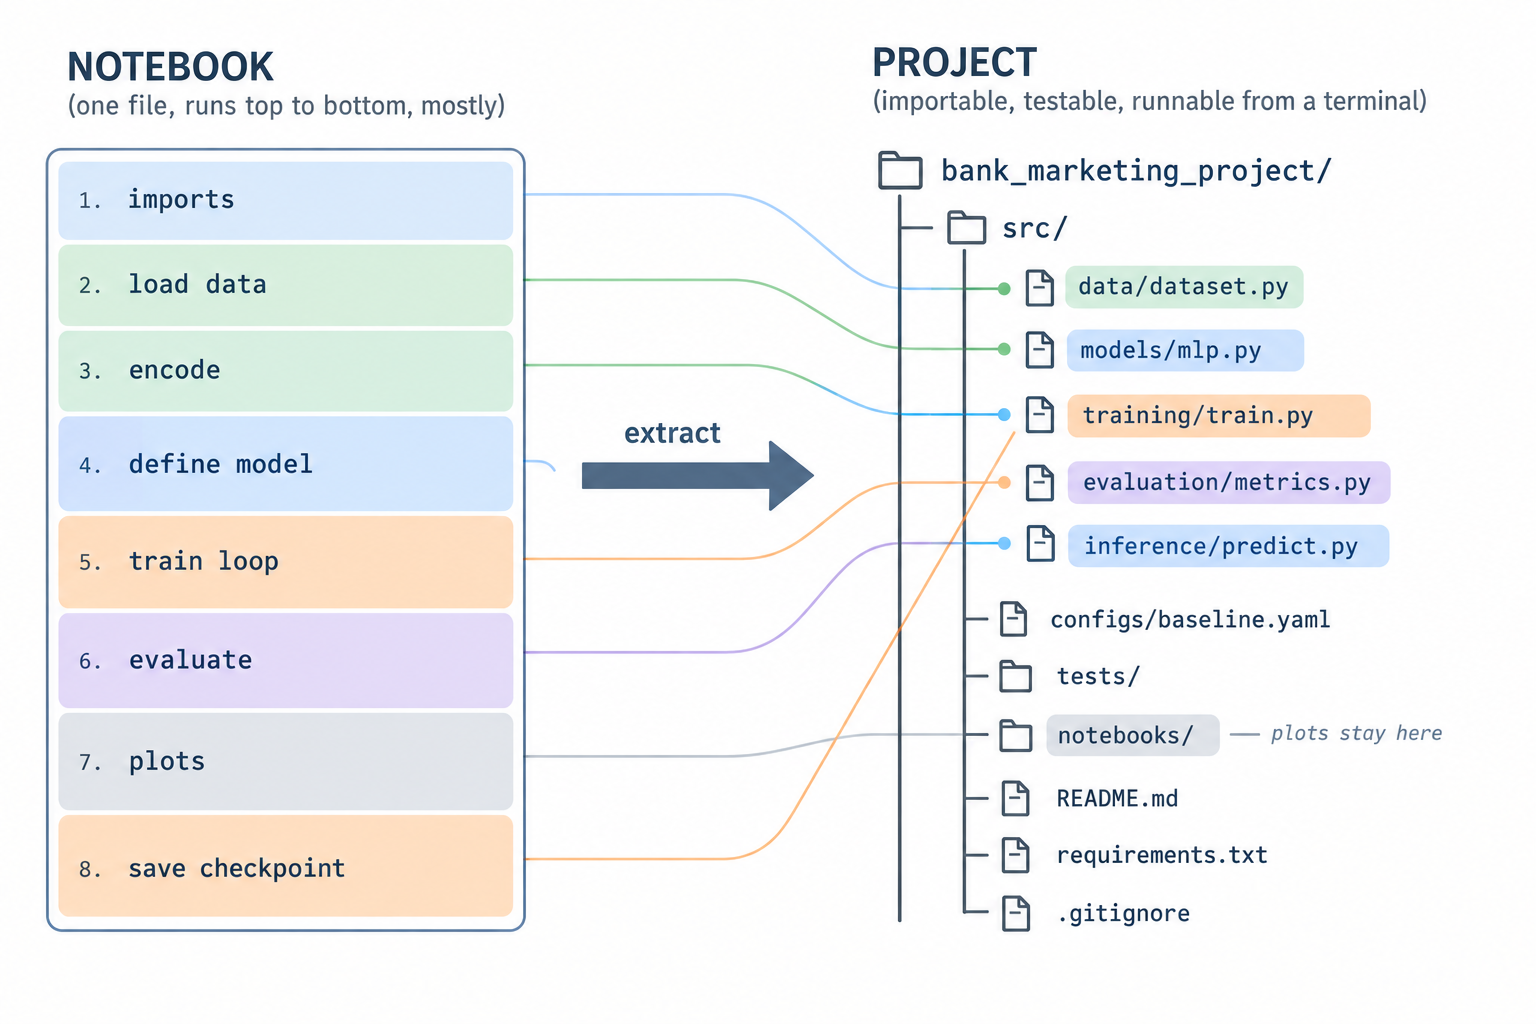


</div>

### The data module

Everything Note 2.2 did to get from a CSV to `float32` arrays, in one importable file. It downloads
if it must, caches if it can, and returns the same splits Note 2.3 trained on.

In [7]:
%%writefile bank_marketing_project/src/data/dataset.py
"""Load, split and encode the UCI Bank Marketing dataset.

Extracted from Day 2 Note 2.2. The `duration` column is dropped as a target leak:
it is only known after the outcome it predicts.
"""
from __future__ import annotations

import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
LEAKY_COLUMNS = ["duration"]


def download(data_dir: Path) -> Path:
    """Fetch bank-full.csv, caching locally. The UCI archive nests a second zip."""
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    csv_path = data_dir / "bank-full.csv"
    if csv_path.exists():
        return csv_path

    outer = data_dir / "bank+marketing.zip"
    urllib.request.urlretrieve(BANK_URL, outer)
    with zipfile.ZipFile(outer) as z:
        z.extract("bank.zip", data_dir)
    with zipfile.ZipFile(data_dir / "bank.zip") as z:
        z.extract("bank-full.csv", data_dir)
    outer.unlink()
    (data_dir / "bank.zip").unlink()
    return csv_path


def load_splits(data_dir: Path, seed: int = 42) -> dict:
    """Return encoded train/val/test arrays. Scaler is fitted on TRAIN only."""
    df = pd.read_csv(download(data_dir), sep=";").drop(columns=LEAKY_COLUMNS)
    y = (df.pop("y") == "yes").astype(np.int64).values

    numeric = [c for c in df.columns if df[c].dtype.kind in "iuf"]
    categorical = [c for c in df.columns if c not in numeric]

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        df, y, test_size=0.30, stratify=y, random_state=seed)
    X_va, X_te, y_va, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=seed)

    train_ohe = pd.get_dummies(X_tr, columns=categorical)
    names = list(train_ohe.columns)
    scaler = StandardScaler().fit(train_ohe[numeric])

    def encode(frame: pd.DataFrame) -> np.ndarray:
        out = (pd.get_dummies(frame, columns=categorical)
               .reindex(columns=names, fill_value=0)
               .astype(np.float32))
        out[numeric] = scaler.transform(out[numeric]).astype(np.float32)
        return out.values.astype(np.float32)

    return {
        "X_train": encode(X_tr), "y_train": y_tr,
        "X_val": encode(X_va), "y_val": y_va,
        "X_test": encode(X_te), "y_test": y_te,
        "feature_names": names,
    }


def make_loaders(splits: dict, batch_size: int = 256, eval_batch_size: int = 1024):
    """Wrap encoded arrays in DataLoaders. Labels are (N, 1) float for BCEWithLogitsLoss."""
    def build(X, y, bs, shuffle):
        ds = TensorDataset(
            torch.from_numpy(X),
            torch.from_numpy(y).float().unsqueeze(1),
        )
        return DataLoader(ds, batch_size=bs, shuffle=shuffle)

    return (
        build(splits["X_train"], splits["y_train"], batch_size, True),
        build(splits["X_val"], splits["y_val"], eval_batch_size, False),
        build(splits["X_test"], splits["y_test"], eval_batch_size, False),
    )

Writing bank_marketing_project/src/data/dataset.py


#### Data-module walkthrough

This file has one job: **turn raw UCI data into consistent model-ready arrays.**

- `download()` downloads the archive only when the CSV is missing and then caches the CSV locally.
- `LEAKY_COLUMNS = ["duration"]` removes a feature that is only known after the outcome. Using it would leak information from the future into the prediction.
- `train_test_split(..., stratify=y)` creates train/temporary splits while preserving the class ratio approximately.
- A second split divides the temporary data into validation and test sets.
- `pd.get_dummies()` converts categorical values into numerical indicator columns.
- `reindex(columns=names, fill_value=0)` forces validation/test to use exactly the training feature columns.
- `StandardScaler().fit(...)` learns scaling statistics from **training data only**. Validation and test are transformed using those already-learned statistics.
- `make_loaders()` converts NumPy arrays to tensors and groups them into mini-batches. Labels become shape `(N, 1)` so they match the model's `(N, 1)` logits.

### The model module

`BankMLP` and `DenseBlock` from Note 2.3, unchanged.

In [8]:
%%writefile bank_marketing_project/src/models/mlp.py
"""The MLP from Day 2 Note 2.3.

The head emits raw logits. Do not add a sigmoid here -- BCEWithLogitsLoss
applies it internally in a numerically stable way.
"""
from __future__ import annotations

import torch.nn as nn


class DenseBlock(nn.Module):
    """Linear -> ReLU. The repeated motif."""

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(self.linear(x))


class BankMLP(nn.Module):
    """Configurable-depth MLP for binary tabular classification."""

    def __init__(self, in_features: int, hidden_sizes=(64, 32), out_features: int = 1):
        super().__init__()
        sizes = [in_features, *hidden_sizes]
        self.blocks = nn.ModuleList(
            DenseBlock(sizes[i], sizes[i + 1]) for i in range(len(hidden_sizes))
        )
        self.head = nn.Linear(sizes[-1], out_features)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.head(x)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

Writing bank_marketing_project/src/models/mlp.py


#### Model-module walkthrough

`DenseBlock` is a small abstraction for the repeated pattern **Linear → ReLU**.

`BankMLP` builds as many of those blocks as `hidden_sizes` requests. For example, `hidden_sizes=(64, 32)` means:

```text
input features → 64 → ReLU → 32 → ReLU → 1 output
```

`nn.ModuleList` is important: PyTorch registers modules placed inside it, so their parameters appear in `model.parameters()` and can be updated by the optimizer.

The final layer deliberately returns **raw logits**, not probabilities. `BCEWithLogitsLoss` expects logits and handles the sigmoid operation internally in a numerically stable way.

### The evaluation module

Metrics separated from training, so inference and any future notebook can import them without
pulling in an optimizer.

In [9]:
%%writefile bank_marketing_project/src/evaluation/metrics.py
"""Evaluation for an imbalanced binary classifier.

Accuracy is deliberately not the headline metric: the majority class is
about 88% of this dataset.
"""
from __future__ import annotations

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import average_precision_score, roc_auc_score


@torch.no_grad()
def evaluate(model: nn.Module, loader, loss_fn, device) -> dict:
    """Run the model over a loader. No gradients, no updates, eval mode."""
    model.eval()
    running_loss, n_seen = 0.0, 0
    probs_chunks, label_chunks = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        running_loss += loss_fn(logits, yb).item() * xb.size(0)
        n_seen += xb.size(0)
        probs_chunks.append(torch.sigmoid(logits).cpu().numpy().ravel())
        label_chunks.append(yb.cpu().numpy().ravel())

    probs = np.concatenate(probs_chunks)
    labels = np.concatenate(label_chunks)

    return {
        "loss": running_loss / n_seen,
        "roc_auc": float(roc_auc_score(labels, probs)),
        "avg_precision": float(average_precision_score(labels, probs)),
        "probs": probs,
        "labels": labels,
    }


def recall_at_budget(probs: np.ndarray, labels: np.ndarray, fraction: float = 0.20) -> float:
    """Share of positives captured by contacting the top `fraction` of the ranking."""
    k = int(len(probs) * fraction)
    top = np.argsort(probs)[::-1][:k]
    return float(labels[top].sum() / labels.sum())

Writing bank_marketing_project/src/evaluation/metrics.py


#### Evaluation-module walkthrough

Evaluation is separate from training so that the same metric code can be reused elsewhere.

- `model.eval()` switches layers that have train/eval behavior into evaluation mode.
- `@torch.no_grad()` prevents gradient tracking because evaluation does not update weights.
- `torch.sigmoid(logits)` converts raw logits into probabilities for metrics.
- ROC-AUC and average precision evaluate the quality of the ranking rather than depending on one arbitrary probability threshold.
- `recall_at_budget(..., fraction=0.20)` asks a business-style question: if we can contact only the top 20% of the ranked list, what fraction of all positive cases do we capture?

### The training module

This is the entry point. It parses a config path, seeds everything, builds the pieces, trains with
early stopping, and writes a checkpoint plus a JSON record of the run.

Note what it does *not* do: no plots, no `print` of anything a human needs to interpret visually.
Those belong in a notebook that imports this module.

In [10]:
%%writefile bank_marketing_project/src/training/train.py
"""Training entry point.

Run from the project root:
    python -m src.training.train --config configs/baseline.yaml
"""
from __future__ import annotations

import argparse
import copy
import json
import os
import random
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import yaml

from src.data.dataset import load_splits, make_loaders
from src.evaluation.metrics import evaluate, recall_at_budget
from src.models.mlp import BankMLP, count_parameters


def seed_everything(seed: int) -> None:
    """Seed every RNG that affects a run."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device(preference: str = "auto") -> torch.device:
    if preference != "auto":
        return torch.device(preference)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")


def train_one_epoch(model, loader, loss_fn, optimizer, device) -> float:
    model.train()
    running_loss, n_seen = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    return running_loss / n_seen


def main(config_path: str) -> dict:
    cfg = yaml.safe_load(Path(config_path).read_text())

    seed_everything(cfg["seed"])
    device = get_device(cfg.get("device", "auto"))

    splits = load_splits(Path(cfg["data_dir"]), seed=cfg["seed"])
    train_loader, val_loader, test_loader = make_loaders(
        splits, batch_size=cfg["batch_size"], eval_batch_size=cfg["eval_batch_size"])

    model = BankMLP(
        in_features=splits["X_train"].shape[1],
        hidden_sizes=tuple(cfg["hidden_sizes"]),
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    loss_fn = nn.BCEWithLogitsLoss()

    print(f"device      : {device}")
    print(f"features    : {splits['X_train'].shape[1]}")
    print(f"train rows  : {splits['X_train'].shape[0]:,}")
    print(f"parameters  : {count_parameters(model):,}")
    print(f"max epochs  : {cfg['max_epochs']} (patience {cfg['patience']})")
    print()

    best_loss, best_epoch, best_weights = float("inf"), 0, None
    stale = 0
    history = []
    started = time.time()

    for epoch in range(1, cfg["max_epochs"] + 1):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val = evaluate(model, val_loader, loss_fn, device)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val["loss"],
            "val_roc_auc": val["roc_auc"],
            "val_avg_precision": val["avg_precision"],
        })
        print(f"epoch {epoch:>3} | train {train_loss:.4f} | val {val['loss']:.4f} "
              f"| ROC-AUC {val['roc_auc']:.4f} | AP {val['avg_precision']:.4f}")

        if val["loss"] < best_loss - cfg["min_delta"]:
            best_loss, best_epoch = val["loss"], epoch
            best_weights = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= cfg["patience"]:
                print(f"\nEarly stop at epoch {epoch} (best was {best_epoch}).")
                break

    model.load_state_dict(best_weights)
    elapsed = time.time() - started

    val_final = evaluate(model, val_loader, loss_fn, device)
    test_final = evaluate(model, test_loader, loss_fn, device)

    print(f"\nBest epoch {best_epoch} | trained in {elapsed:.1f}s")
    print(f"VAL   loss {val_final['loss']:.4f} | ROC-AUC {val_final['roc_auc']:.4f} "
          f"| AP {val_final['avg_precision']:.4f}")
    print(f"TEST  loss {test_final['loss']:.4f} | ROC-AUC {test_final['roc_auc']:.4f} "
          f"| AP {test_final['avg_precision']:.4f}")
    print(f"TEST  recall at 20% budget: "
          f"{recall_at_budget(test_final['probs'], test_final['labels']):.4f}")

    ckpt_dir = Path(cfg["checkpoint_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": best_epoch,
        "config": cfg,
        "in_features": splits["X_train"].shape[1],
        "torch_version": torch.__version__,
    }, ckpt_dir / f"{cfg['run_name']}.pt")

    record = {
        "run_name": cfg["run_name"],
        "config": cfg,
        "best_epoch": best_epoch,
        "elapsed_seconds": round(elapsed, 2),
        "history": history,
        "val": {k: v for k, v in val_final.items() if k not in ("probs", "labels")},
        "test": {k: v for k, v in test_final.items() if k not in ("probs", "labels")},
        "torch_version": torch.__version__,
    }
    (ckpt_dir / f"{cfg['run_name']}_results.json").write_text(json.dumps(record, indent=2))
    print(f"\nSaved {ckpt_dir / (cfg['run_name'] + '.pt')}")
    print(f"Saved {ckpt_dir / (cfg['run_name'] + '_results.json')}")
    return record


if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Train the Bank Marketing MLP.")
    parser.add_argument("--config", required=True, help="path to a YAML config")
    args = parser.parse_args()
    main(args.config)

Writing bank_marketing_project/src/training/train.py


#### Training-module walkthrough

Think of `main()` as an assembly line:

```text
read YAML
  ↓
set random seed
  ↓
choose device
  ↓
load/preprocess data
  ↓
build model + optimizer + loss
  ↓
repeat epochs
  ↓
validate
  ↓
keep best weights / early-stop
  ↓
evaluate validation + test
  ↓
save checkpoint + JSON results
```

The important separation is that the **procedure lives in Python**, while the **numbers that define a particular experiment live in YAML**.

### The inference module

Training and inference are different programs. This one loads a checkpoint, rebuilds the
architecture from the config stored inside it, and scores new rows. It never imports the optimizer.

In [11]:
%%writefile bank_marketing_project/src/inference/predict.py
"""Load a checkpoint and score new examples."""
from __future__ import annotations

from pathlib import Path

import numpy as np
import torch

from src.models.mlp import BankMLP


def load_model(checkpoint_path: Path, device: torch.device | str = "cpu") -> torch.nn.Module:
    """Rebuild the architecture from the checkpoint's own config, then load weights."""
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = BankMLP(
        in_features=ckpt["in_features"],
        hidden_sizes=tuple(ckpt["config"]["hidden_sizes"]),
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


@torch.no_grad()
def predict_proba(model: torch.nn.Module, X: np.ndarray, device="cpu") -> np.ndarray:
    """Return P(subscribe) for each row. Input must already be encoded."""
    tensor = torch.from_numpy(np.asarray(X, dtype=np.float32)).to(device)
    if tensor.ndim == 1:                     # a single row -- restore the batch axis
        tensor = tensor.unsqueeze(0)
    return torch.sigmoid(model(tensor)).cpu().numpy().ravel()


def rank_by_score(probs: np.ndarray, top_k: int) -> np.ndarray:
    """Indices of the top_k highest-scoring rows, best first."""
    return np.argsort(probs)[::-1][:top_k]

Writing bank_marketing_project/src/inference/predict.py


#### Inference-module walkthrough

Inference is deliberately smaller than training. It does not need an optimizer, gradients, or epochs.

- `load_model()` reads the saved architecture settings and weights from the checkpoint.
- `predict_proba()` accepts already-encoded features, restores a missing batch dimension when the caller supplies one row, runs the model without gradients, and converts logits to probabilities.
- `rank_by_score()` returns the indices of the highest-scoring rows first.

This separation matters in deployment: a prediction service should not need to import or execute the training loop just to score a customer.

**Questions to sit with:**

1. `src/inference/predict.py` imports the model but never the training module. What would break —
   practically, at deployment — if inference imported `train.py` instead?
2. `predict_proba` restores a missing batch axis with `unsqueeze(0)`. That is Note 2.1's Case 2.
   Why is silently fixing it defensible here, when Note 2.1 argued that silent fixes are dangerous?

<a id="s4"></a>
## 4. Configuration and seeds

Every number that changes between runs belongs in a config file, not in the code. A useful rule:

> **If changing a value should create a new experiment but should not require rewriting the algorithm, put that value in the config.**

Here that means the random seed, batch size, hidden-layer sizes, learning rate, maximum epochs, early-stopping patience, and output directory. The Python program stays the same while the YAML file describes one particular run. The payoff is that a run is fully described by a file you can commit, diff and attach to a result.

In [12]:
%%writefile bank_marketing_project/configs/baseline.yaml
# Baseline configuration -- Day 2 Note 2.3 reproduced from the command line.
run_name: baseline

# Reproducibility
seed: 42
device: auto            # auto | cpu | cuda | mps

# Data
data_dir: data
batch_size: 256
eval_batch_size: 1024

# Model
hidden_sizes: [64, 32]

# Optimisation
learning_rate: 0.001
max_epochs: 40
patience: 5
min_delta: 0.0001

# Output
checkpoint_dir: checkpoints

Writing bank_marketing_project/configs/baseline.yaml


In [13]:
%%writefile bank_marketing_project/configs/wide.yaml
# A second experiment: more capacity, everything else identical.
# Run it with: python -m src.training.train --config configs/wide.yaml
run_name: wide

seed: 42
device: auto

data_dir: data
batch_size: 256
eval_batch_size: 1024

hidden_sizes: [256, 128, 64]

learning_rate: 0.001
max_epochs: 40
patience: 5
min_delta: 0.0001

checkpoint_dir: checkpoints

Writing bank_marketing_project/configs/wide.yaml


Those two files differ in exactly two settings, `run_name` and `hidden_sizes`. That is the point: the diff between them *is* the experiment, and it is reviewable.

### Why the two YAML files are an experiment

The baseline and wide configurations use the same seed, data handling, batch sizes, learning rate, and stopping rules. The meaningful change is the hidden-layer configuration:

```text
baseline: [64, 32]
wide:     [256, 128, 64]
```

That makes the question precise: **what changes when model capacity is increased while the rest of the setup is held constant?**

### Seeding, and what stays random anyway

`seed_everything` in `train.py` seeds Python's `random`, NumPy, and PyTorch's CPU and CUDA
generators. That covers weight initialisation, `DataLoader` shuffling, and dropout.

It does not make a run bit-for-bit deterministic, and it is worth knowing why rather than being
surprised later:

- **GPU floating-point reduction order** varies between runs. Summing the same numbers in a
  different order gives slightly different results, and the difference compounds over epochs.
- **cuDNN picks algorithms adaptively** based on input shapes and available memory. Different
  algorithm, different arithmetic.
- **Multiple `DataLoader` workers** complete in nondeterministic order unless separately seeded.

Treat the seed as a reproducibility aid, not a guarantee of identical bits, and expect small differences between CPU, CUDA and MPS even with the same seed. Full determinism is available and costs speed:

```python
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
```

Turn it on when you are chasing a bug that only appears sometimes. Leave it off otherwise, and
report a mean and a spread over several seeds rather than pretending one run is the answer. Day 4
takes this up properly.

### Tests that need no training

The last file this section writes is the test suite. Each test checks one promise the modules above make (a shape, a logit, a registered parameter) and none of them trains a network, so the whole file runs in about a second.

In [14]:
%%writefile bank_marketing_project/tests/test_shapes.py
"""Tests that catch shape and contract bugs without training anything.

Run from the project root:
    python -m pytest tests/ -v
"""
import numpy as np
import torch
import torch.nn as nn

from src.models.mlp import BankMLP, count_parameters
from src.inference.predict import predict_proba


def test_forward_shape():
    """A batch of N rows must produce N logits."""
    model = BankMLP(in_features=50, hidden_sizes=(64, 32))
    out = model(torch.randn(8, 50))
    assert out.shape == (8, 1), f"expected (8, 1), got {tuple(out.shape)}"


def test_parameter_count():
    """Guards against layers stored in a plain list, which the optimizer never sees."""
    model = BankMLP(in_features=50, hidden_sizes=(64, 32))
    expected = (50 * 64 + 64) + (64 * 32 + 32) + (32 * 1 + 1)
    assert count_parameters(model) == expected


def test_head_emits_logits_not_probabilities():
    """A sigmoid in forward() would trap every output in [0, 1]."""
    model = BankMLP(in_features=50, hidden_sizes=(64, 32))
    with torch.no_grad():
        out = model(torch.randn(512, 50) * 10)
    assert out.min() < 0.0 or out.max() > 1.0, "output looks bounded -- sigmoid in forward()?"


def test_loss_shapes_match():
    """Note 2.1 Case 5: mismatched shapes broadcast silently in some losses."""
    model = BankMLP(in_features=50, hidden_sizes=(64, 32))
    logits = model(torch.randn(16, 50))
    labels = torch.randint(0, 2, (16, 1)).float()
    assert logits.shape == labels.shape
    loss = nn.BCEWithLogitsLoss()(logits, labels)
    assert loss.ndim == 0, "loss must be a scalar for .backward()"


def test_single_row_inference():
    """Deployment passes one record, not a batch."""
    model = BankMLP(in_features=50, hidden_sizes=(64, 32))
    probs = predict_proba(model, np.random.randn(50).astype(np.float32))
    assert probs.shape == (1,)
    assert 0.0 <= probs[0] <= 1.0


def test_configurable_depth():
    """hidden_sizes drives depth; a three-layer config must build and run."""
    model = BankMLP(in_features=50, hidden_sizes=(256, 128, 64))
    assert model(torch.randn(4, 50)).shape == (4, 1)
    assert len(model.blocks) == 3

Writing bank_marketing_project/tests/test_shapes.py


#### What each test protects

1. **Forward shape:** `N` input rows must produce `N` logits.
2. **Parameter count:** catches a model-construction mistake such as storing trainable layers in an ordinary Python list instead of a PyTorch module container.
3. **Logits contract:** catches an accidental sigmoid in `forward()`.
4. **Loss shapes:** makes sure logits and labels have the same shape instead of relying on broadcasting.
5. **Single-row inference:** verifies that a one-dimensional feature vector is interpreted as one example.
6. **Configurable depth:** verifies that changing `hidden_sizes` really changes the architecture.

Six tests, none of which trains anything, all of which run in under a second. Between them they
catch every silent bug Notes 2.1 and 2.3 identified: the broadcast mismatch, the sigmoid in
`forward`, the unregistered parameters, the missing batch axis.

This is the argument for tests in a machine-learning project. They cannot tell you the model is
*good* — that is what your validation set is for. They can tell you the plumbing is intact, in a
second, before you spend an hour training something that was never going to work.

**Questions to sit with:**

1. `test_head_emits_logits_not_probabilities` multiplies its input by 10 before checking the output
   range. Why is that scaling necessary for the test to be reliable?
2. Name one property of the *trained* model you could test automatically, and one you could not.
   What distinguishes them?

<a id="s5"></a>
## 5. Training from the command line

Everything is in place. Before training, run the tests — they take a second and they are the reason
you will not discover a shape bug forty epochs in.

In [15]:
def run_in_project(command: list[str], timeout: int = 900) -> subprocess.CompletedProcess:
    """Run a command from the project root, with the project on PYTHONPATH."""
    env = dict(os.environ, PYTHONPATH=str(PROJECT.resolve()))
    result = subprocess.run(
        command, cwd=PROJECT, env=env,
        capture_output=True, text=True, timeout=timeout,
    )
    print(result.stdout)
    if result.returncode != 0:
        print("--- stderr ---")
        print(result.stderr[-3000:])
    return result


def ensure_pytest():
    # Some managed environments (PEP 668) refuse a plain pip install.
    # Try the normal route first, then the override.
    try:
        import pytest  # noqa: F401
        return True
    except ImportError:
        pass
    print("pytest not found. Installing ...")
    for extra in ([], ["--break-system-packages"]):
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytest"] + extra,
                           capture_output=True, text=True)
        if r.returncode == 0:
            return True
    print("Could not install pytest automatically. Run: pip install pytest")
    return False

have_pytest = ensure_pytest()

test_run = run_in_project([sys.executable, "-m", "pytest", "tests/", "-v", "--no-header", "-q"])
print(f"\nExit code: {test_run.returncode}  (0 means every test passed)")

============================= test session starts ==============================
collected 6 items

tests/test_shapes.py ......                                              [100%]

============================== 6 passed in 0.53s ===============================


Exit code: 0  (0 means every test passed)


### The run itself

This is the moment the note exists for. No notebook, no cells, no hidden state — a config file and a module path:

```bash
python -m src.training.train --config configs/baseline.yaml
```

Read it as: **"Use Python to execute the `src.training.train` module and give it the baseline configuration."** There is no notebook execution order involved; the configuration and the imported modules define what happens.

In [16]:
# Reuse the already-downloaded CSV if this notebook's folder has one, to save a download.
local_csv = Path("data/bank-full.csv")
if local_csv.exists():
    shutil.copy(local_csv, PROJECT / "data" / "bank-full.csv")
    print("Reused the cached CSV from this notebook's data/ folder.\n")

import time as _time
t0 = _time.time()
train_run = run_in_project([
    sys.executable, "-m", "src.training.train", "--config", "configs/baseline.yaml"
])
print(f"\nWall clock: {_time.time() - t0:.1f}s | exit code {train_run.returncode}")

device      : mps
features    : 50
train rows  : 31,647
parameters  : 5,377
max epochs  : 40 (patience 5)

epoch   1 | train 0.3867 | val 0.3118 | ROC-AUC 0.7641 | AP 0.3944
epoch   2 | train 0.3069 | val 0.2963 | ROC-AUC 0.7771 | AP 0.4221
epoch   3 | train 0.2976 | val 0.2914 | ROC-AUC 0.7833 | AP 0.4366
epoch   4 | train 0.2942 | val 0.2904 | ROC-AUC 0.7859 | AP 0.4417
epoch   5 | train 0.2920 | val 0.2886 | ROC-AUC 0.7892 | AP 0.4455
epoch   6 | train 0.2899 | val 0.2868 | ROC-AUC 0.7921 | AP 0.4490
epoch   7 | train 0.2882 | val 0.2871 | ROC-AUC 0.7939 | AP 0.4522
epoch   8 | train 0.2861 | val 0.2869 | ROC-AUC 0.7937 | AP 0.4499
epoch   9 | train 0.2855 | val 0.2856 | ROC-AUC 0.7949 | AP 0.4483
epoch  10 | train 0.2835 | val 0.2900 | ROC-AUC 0.7975 | AP 0.4528
epoch  11 | train 0.2836 | val 0.2846 | ROC-AUC 0.7982 | AP 0.4515
epoch  12 | train 0.2808 | val 0.2857 | ROC-AUC 0.7953 | AP 0.4492
epoch  13 | train 0.2798 | val 0.2846 | ROC-AUC 0.7973 | AP 0.4495
epoch  14 | train 0.27

That output should look familiar. Early stopping triggers at roughly the epoch Note 2.3 found, the
validation ROC-AUC lands in the same place, and this time there is also a **test-set** number —
the first time in Day 2 we have touched it, and the last time we should until the project is
finished.

The run left two artifacts behind.

In [17]:
results_path = PROJECT / "checkpoints" / "baseline_results.json"
record = json.loads(results_path.read_text())

print(f"Run '{record['run_name']}' — best epoch {record['best_epoch']} "
      f"of {len(record['history'])} run, in {record['elapsed_seconds']}s\n")

print(f"{'split':<8}{'loss':>10}{'ROC-AUC':>11}{'avg prec':>11}")
print("-" * 40)
for split in ("val", "test"):
    r = record[split]
    print(f"{split:<8}{r['loss']:>10.4f}{r['roc_auc']:>11.4f}{r['avg_precision']:>11.4f}")

gap = record["val"]["roc_auc"] - record["test"]["roc_auc"]
print(f"\nval - test ROC-AUC gap: {gap:+.4f}")
print("Validation is mildly optimistic because early stopping selected an epoch")
print("using it. The test set was never used for any decision, which is what")
print("makes it the number you would quote.")

print(f"\nFiles written by the run:")
for f in sorted((PROJECT / "checkpoints").iterdir()):
    print(f"  {f.name:<32} {f.stat().st_size / 1024:>8.1f} KB")

Run 'baseline' — best epoch 11 of 16 run, in 3.61s

split         loss    ROC-AUC   avg prec
----------------------------------------
val         0.2846     0.7982     0.4515
test        0.2888     0.7872     0.4355

val - test ROC-AUC gap: +0.0110
Validation is mildly optimistic because early stopping selected an epoch
using it. The test set was never used for any decision, which is what
makes it the number you would quote.

Files written by the run:
  baseline.pt                          71.2 KB
  baseline_results.json                 3.8 KB


### How to interpret the training result

Do not treat the exact printed decimals as universal constants. They depend on the code version, dependency versions, hardware backend, and randomness. The useful engineering evidence is:

- the command completed successfully;
- the expected train/validation/test pipeline ran;
- early stopping selected a best epoch;
- a checkpoint was written;
- a JSON experiment record was written;
- the held-out test set was evaluated only after model selection.

Validation can be slightly better than test because validation performance influenced the choice of the best epoch. A much larger gap would be a reason to investigate overfitting, split design, preprocessing, or other sources of distribution mismatch.

In [18]:
# The config fully describes the run, so a second experiment is a second file.
# Strip comments and blank lines first: only the settings define the run.
base, wide = [
    [line.split("#")[0].rstrip()
     for line in (PROJECT / "configs" / name).read_text().splitlines()
     if line.split("#")[0].strip()]
    for name in ("baseline.yaml", "wide.yaml")
]

import difflib
changed = sum(1 for line in difflib.ndiff(base, wide) if line.startswith("+ "))
print(f"Two configs, comments ignored, differing in {changed} lines:\n")
for line in difflib.unified_diff(base, wide, "baseline.yaml", "wide.yaml", lineterm="", n=0):
    print(" ", line)

print("\nRun it with:")
print("  python -m src.training.train --config configs/wide.yaml")
print("\nWe are not running it here to keep this note under a minute, but it is")
print("exercise 2 from Note 2.3 Section 9, now a second config file rather")
print("than an edit to the code.")

Two configs, comments ignored, differing in 2 lines:

  --- baseline.yaml
  +++ wide.yaml
  @@ -1 +1 @@
  -run_name: baseline
  +run_name: wide
  @@ -7 +7 @@
  -hidden_sizes: [64, 32]
  +hidden_sizes: [256, 128, 64]

Run it with:
  python -m src.training.train --config configs/wide.yaml

We are not running it here to keep this note under a minute, but it is
exercise 2 from Note 2.3 Section 9, now a second config file rather
than an edit to the code.


**Questions to sit with:**

1. The test ROC-AUC came out slightly below validation. Explain the mechanism, and say what you
   would conclude if the gap had been ten times larger.
2. `run_in_project` sets `PYTHONPATH` so that `from src.models.mlp import BankMLP` resolves. What
   is the alternative that a real project uses instead, and why is it better than setting an
   environment variable? (Search for "editable install" and `pyproject.toml`.)

<a id="s6"></a>
## 6. Git a reviewer can understand

Git is not only backup. It is a **history of deliberate changes**, and a repository is a communication medium. A good one makes it possible to answer:

- What changed?
- Why did it change?
- Which configuration produced this experiment?
- Can I reproduce or undo the change?

Three things decide whether a reviewer can answer those: what you exclude, how you commit, and what your README says.

### What to exclude

The rule is that **anything reproducible from what you committed should not be committed.** Data is regenerable by your download script. Checkpoints are regenerable by your training script. Notebook outputs regenerate when the notebook runs.

In [19]:
%%writefile bank_marketing_project/.gitignore
# Data -- regenerable by src/data/dataset.py
# The leading slash anchors this to the project root. Without it the pattern
# also matches src/data/ and silently excludes your own source code.
/data/
*.csv
*.npz
*.zip

# Model artifacts -- regenerable by src/training/train.py
checkpoints/
*.pt
*.pth
*.onnx

# Environments
.venv/
venv/
env/

# Python
__pycache__/
*.py[cod]
*.egg-info/
.pytest_cache/

# Notebooks: strip outputs before committing (see nbstripout)
.ipynb_checkpoints/

# Editors and OS
.vscode/
.idea/
.DS_Store

# Secrets -- never commit these
.env
*.key
credentials.json

Writing bank_marketing_project/.gitignore


### Should the dataset be committed?

The `data/` exclusion is the one people argue about. The argument for excluding it: a 5 MB CSV
becomes a 5 MB blob in your history forever, git handles binary poorly, and large files make
cloning slow. The argument for including it: reproducibility depends on the exact data.

The resolution used here, and standard in 2026: **commit the code that fetches the data, not the
data.** `src/data/dataset.py` contains the URL and the exact preprocessing, which is a more precise
specification than the file itself. When the data is not publicly fetchable, the answer is a data
version-control tool rather than git. Private, licensed or changing data means making the decision again; what carries over is the principle of making the data's provenance, and how to retrieve it, explicit.

Notebook outputs deserve a note. `.ipynb_checkpoints/` catches Jupyter's autosaves, but the real
problem is the outputs inside the committed `.ipynb` — Section 1 measured how much of the file they
are. The standard fix is `nbstripout`, a git filter that removes outputs on commit:

```bash
pip install nbstripout
nbstripout --install          # run once, inside the repository
```

### The README

Day 10 requires twelve specific sections. Writing the skeleton now means filling it in as you go
rather than reconstructing it from memory at the end.

In [20]:
%%writefile bank_marketing_project/README.md
# Bank Marketing — Term Deposit Subscription

Predict whether a client contacted in a Portuguese bank's direct marketing campaign
will subscribe to a term deposit.

Built during Day 2 of *Modern Deep Learning & AI Engineering*.

---

## 1. Problem statement

Binary classification on tabular data. The operational goal is **ranking**, not
labelling: the call centre can contact a limited fraction of the list, so what
matters is whether the highest-scoring clients are the ones who subscribe.

## 2. Dataset

UCI Bank Marketing (`bank-full.csv`), 45,211 rows, 16 features after dropping one.

- Source: https://archive.ics.uci.edu/dataset/222/bank+marketing
- Downloaded automatically by `src/data/dataset.py`; not committed.
- **Positive rate 11.7%.** A model predicting "no" for everyone scores 88.3% accuracy
  and is worthless. Accuracy is not reported.
- **`duration` is dropped as a target leak** — call length is only known after the
  call, by which point the outcome is known. The UCI documentation says the same.

Split 70/15/15, stratified, seed 42. The scaler is fitted on the training split only.

## 3. Approach

One-hot encode 9 categorical columns, standardise 6 numeric columns, feed a small MLP.
Raw logits out; `BCEWithLogitsLoss` applies the sigmoid internally for numerical stability.

## 4. Baseline

| Model | ROC-AUC | Average precision |
|---|---|---|
| Majority class | 0.500 | 0.117 (= positive rate) |
| Logistic regression | see results | see results |

The logistic regression is the baseline that matters: the network has to beat it to
justify its complexity.

## 5. Model architecture

`BankMLP`: 50 → 64 → ReLU → 32 → ReLU → 1 logit. About 5,400 parameters.
Depth and width are configurable via `hidden_sizes` in the config.

## 6. Training procedure

Adam, learning rate 1e-3, batch size 256, up to 40 epochs with early stopping
(patience 5 on validation loss, restoring the best weights).
Fully specified by `configs/baseline.yaml`.

## 7. Evaluation

ROC-AUC and average precision. Accuracy is excluded deliberately (see §2).
Also reported: recall at a 20% contact budget, which is the operational metric.

## 8. Results

Written to `checkpoints/<run_name>_results.json` by every run. See that file for the
current numbers; it records the full config alongside them.

## 9. Error analysis

TODO — Day 9 covers this properly.

## 10. Limitations

- Tabular data is where deep learning has the least advantage; the MLP beats logistic
  regression by a small margin at a large cost in complexity. Day 4 tests this against
  gradient boosting under a controlled protocol.
- The random split ignores the campaign's strong temporal ordering. A time-based split
  would be a harder and more honest evaluation.
- No hyperparameter search has been run. Day 3.
- Validation is mildly optimistic because early stopping selects an epoch using it.
  Quote the test number.

## 11. How to run

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt          # see the note about torch inside
python -m pytest tests/ -v
python -m src.training.train --config configs/baseline.yaml
```

## 12. How to perform inference

```python
from src.inference.predict import load_model, predict_proba, rank_by_score
from src.data.dataset import load_splits

model = load_model("checkpoints/baseline.pt")
splits = load_splits("data")
probs = predict_proba(model, splits["X_test"])
top_100 = rank_by_score(probs, top_k=100)      # who to call first
```

Inputs must be encoded by `src/data/dataset.py`. A raw CSV row will not work.

Writing bank_marketing_project/README.md


In [21]:
%%writefile bank_marketing_project/requirements.txt
# Direct dependencies only, pinned to versions observed/tested for this notebook.
#
# IMPORTANT: install torch with the platform-appropriate command below.
# NVIDIA GPU (CUDA 12.4 build):
#   pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu124
# Apple Silicon / CPU default wheel:
#   pip install torch==2.14.0
# CPU-only explicit wheel:
#   pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cpu
#
# After installing the appropriate torch build, install the remaining packages:
#   pip install -r requirements.txt
#
# The torch line remains here as documentation of the tested version; if you use a
# platform-specific index URL, pip may resolve that line from the configured index.

torch==2.14.0
numpy==2.3.5
pandas==2.3.3
scikit-learn==1.7.2
matplotlib==3.10.0
pyyaml==6.0.3

# Development/test dependency
pytest==8.4.2

Writing bank_marketing_project/requirements.txt


### Commits

A commit is a unit of review: a saved point in history that should represent one logical change. The useful discipline is one logical change per commit, with a
message that says *why*, since the diff already says *what*.

```
Bad:   "update"
Bad:   "fixed stuff"
Bad:   "changes to train.py, dataset.py, mlp.py and configs"

Good:  "Drop duration column as target leak"
Good:  "Add early stopping with patience 5 on validation loss"
Good:  "Move hyperparameters into configs/baseline.yaml"
```

Note that the good messages are in the imperative mood and each describes one change. That is not
an aesthetic preference — it is what makes `git log --oneline` readable as a narrative, and what
makes `git revert` on a single commit possible.

In [22]:
# Initialise the repository and make a first commit.
def git(*args, check=True):
    result = subprocess.run(
        ["git", "-c", "user.email=learner@example.com", "-c", "user.name=Learner", *args],
        cwd=PROJECT, capture_output=True, text=True,
    )
    return result


git("init", "-q")
git("add", "-A")
commit = git("commit", "-q", "-m",
             "Add Bank Marketing MLP: data pipeline, model, training and tests")
print(git("log", "--oneline").stdout or "(no commits)")

status = git("status", "--porcelain").stdout
print(f"\nUntracked or modified after commit: "
      f"{len(status.splitlines())} files  (0 means .gitignore is doing its job)")

tracked = git("ls-files").stdout.strip().splitlines()
print(f"\n{len(tracked)} files tracked:")
for f in tracked:
    print(f"  {f}")

5ed90b9 Add Bank Marketing MLP: data pipeline, model, training and tests


Untracked or modified after commit: 0 files  (0 means .gitignore is doing its job)

18 files tracked:
  .gitignore
  README.md
  configs/baseline.yaml
  configs/wide.yaml
  requirements.txt
  src/__init__.py
  src/data/__init__.py
  src/data/dataset.py
  src/evaluation/__init__.py
  src/evaluation/metrics.py
  src/inference/__init__.py
  src/inference/predict.py
  src/models/__init__.py
  src/models/mlp.py
  src/training/__init__.py
  src/training/train.py
  tests/__init__.py
  tests/test_shapes.py


In [23]:
# What .gitignore kept out, and how much it saved.
ignored = git("status", "--ignored", "--porcelain").stdout.splitlines()
ignored_paths = [line[3:] for line in ignored if line.startswith("!!")]

def dir_size(p: Path) -> int:
    if p.is_file():
        return p.stat().st_size
    return sum(f.stat().st_size for f in p.rglob("*") if f.is_file())

total_ignored = 0
print("Excluded from version control:")
for rel in ignored_paths:
    path = PROJECT / rel
    if path.exists():
        size = dir_size(path)
        total_ignored += size
        print(f"  {rel:<24} {size / 1024:>9,.0f} KB")

tracked_size = sum((PROJECT / f).stat().st_size for f in tracked if (PROJECT / f).exists())
print(f"\n  tracked   : {tracked_size / 1024:>9,.0f} KB")
print(f"  ignored   : {total_ignored / 1024:>9,.0f} KB")
print(f"\nThe repository is {tracked_size / max(total_ignored, 1) * 100:.1f}% "
      f"the size of the working directory — and everything excluded")
print("regenerates from what was committed.")

Excluded from version control:
  .pytest_cache/                   1 KB
  checkpoints/                    75 KB
  data/                        4,502 KB
  src/__pycache__/                 0 KB
  src/data/__pycache__/            5 KB
  src/evaluation/__pycache__/         3 KB
  src/inference/__pycache__/         3 KB
  src/models/__pycache__/          3 KB
  src/training/__pycache__/         9 KB
  tests/__pycache__/              13 KB

  tracked   :        20 KB
  ignored   :     4,614 KB

The repository is 0.4% the size of the working directory — and everything excluded
regenerates from what was committed.


### Verify that .gitignore did not eat your source code

`.gitignore` patterns without a leading slash match **at every level of the tree**, not just the
project root. A rule as ordinary as `data/` will happily match `src/data/` and remove your own
loader module from the repository. Nothing warns you. The working directory looks perfect, the
tests pass, and the person who clones your repo gets an `ImportError`.

That is why the pattern above is `/data/` rather than `data/`. The leading slash anchors it.

Do not take that on trust. Check it, and make the check something a machine can fail.

In [24]:
# Every Python file under src/ and tests/ must be tracked. No exceptions.
source_files = sorted(
    str(p.relative_to(PROJECT))
    for p in PROJECT.rglob("*.py")
    if "__pycache__" not in p.parts
)
tracked_set = set(git("ls-files").stdout.split())

missing = [f for f in source_files if f not in tracked_set]

print(f"{len(source_files)} Python files on disk, {len(missing)} of them untracked")
if missing:
    print("\nMISSING FROM THE REPOSITORY:")
    for f in missing:
        reason = git("check-ignore", "-v", f).stdout.strip()
        print(f"  {f}   <- {reason or 'not ignored, simply never added'}")
else:
    print("every source file is committed")

assert not missing, "source code is missing from the repository"

13 Python files on disk, 0 of them untracked
every source file is committed


In [25]:
# Prove the one-character difference, in a throwaway repo so nothing here is at risk.
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    scratch = Path(tmp)
    (scratch / "src" / "data").mkdir(parents=True)
    (scratch / "data").mkdir()
    (scratch / "src" / "data" / "dataset.py").touch()
    (scratch / "data" / "bank-full.csv").touch()

    subprocess.run(["git", "init", "-q"], cwd=scratch, check=True)

    for pattern in ["data/", "/data/"]:
        (scratch / ".gitignore").write_text(pattern + chr(10))
        print(f"pattern {pattern!r}")
        for candidate in ["data/bank-full.csv", "src/data/dataset.py"]:
            hit = subprocess.run(["git", "check-ignore", "-q", candidate],
                                 cwd=scratch, capture_output=True)
            verdict = "IGNORED" if hit.returncode == 0 else "kept"
            note = ""
            if candidate.startswith("src/") and verdict == "IGNORED":
                note = "   <-- your source code, silently gone"
            print(f"    {candidate:<26} -> {verdict}{note}")
        print()

print("One character. Use `git check-ignore -v <path>` to find which rule matched a file.")

pattern 'data/'
    data/bank-full.csv         -> IGNORED
    src/data/dataset.py        -> IGNORED   <-- your source code, silently gone

pattern '/data/'
    data/bank-full.csv         -> IGNORED
    src/data/dataset.py        -> kept

One character. Use `git check-ignore -v <path>` to find which rule matched a file.


### Pushing it

The notebook can initialise and commit a local repository, but publishing it needs a remote repository and your credentials, so the remaining steps happen in a terminal:

```text
local project → git commit → remote GitHub repository → git push
```


```bash
# Create an empty repository on github.com first, then:
git remote add origin https://github.com/<you>/bank-marketing-mlp.git
git branch -M main
git push -u origin main
```

Branches are worth using from the start, even working alone. `main` holds what works; experiments
live on a branch:

```bash
git checkout -b experiment/wider-network
# edit configs/wide.yaml, run it, commit the results JSON
git checkout main
git merge experiment/wider-network       # only if it was actually better
```

The habit that matters most for this course: **commit the results JSON alongside the config that
produced it.** Six weeks from now, "which settings gave 0.80?" is a question you will want git to
answer rather than your memory.

**Questions to sit with:**

1. `.gitignore` excludes `checkpoints/`. Day 10 requires a working demo. How do you distribute a
   trained model to someone who clones your repository?
2. The commit above bundled the entire project into one commit. That was reasonable for an initial
   scaffold. Split the same work into the four or five commits you would have made if you had
   written it incrementally.

<a id="s7"></a>
## 7. Conclusion

### Save your work before the runtime disappears

On Colab or Kaggle the runtime will eventually recycle, and the generated project is just files in that runtime: everything above disappears with it. Run this cell and download the archive. On a persistent local machine, the Git repository is the durable record.

In [26]:
archive_base = "bank_marketing_project"
archive = shutil.make_archive(archive_base, "zip", root_dir=".", base_dir=PROJECT.name)
size_kb = Path(archive).stat().st_size / 1024

print(f"Created {archive} ({size_kb:.0f} KB)")
print()

try:
    from google.colab import files          # noqa: F401
    on_colab = True
except ImportError:
    on_colab = False

if on_colab:
    print("On Colab. Run this to download it:")
    print("    from google.colab import files")
    print(f"    files.download('{Path(archive).name}')")
else:
    print("Running locally or on Kaggle.")
    print(f"  Local  : the project is already at {PROJECT.resolve()}")
    print("           cd into it and 'git remote add origin ...' to push.")
    print(f"  Kaggle : find {Path(archive).name} in the output panel on the right.")

print(f"\nContents ({len(tracked)} tracked files, plus the run's artifacts):")
for f in sorted(PROJECT.rglob("*")):
    if f.is_file() and ".git/" not in str(f) and "__pycache__" not in str(f):
        print(f"  {f.relative_to(PROJECT)}")

Created /Users/solomonpromise/Documents/Simplilearn Classes/Deep Learning/Day 2/bank_marketing_project.zip (641 KB)

Running locally or on Kaggle.
  Local  : the project is already at /Users/solomonpromise/Documents/Simplilearn Classes/Deep Learning/Day 2/bank_marketing_project
           cd into it and 'git remote add origin ...' to push.
  Kaggle : find bank_marketing_project.zip in the output panel on the right.

Contents (18 tracked files, plus the run's artifacts):
  .gitignore
  .pytest_cache/.gitignore
  .pytest_cache/CACHEDIR.TAG
  .pytest_cache/README.md
  .pytest_cache/v/cache/nodeids
  .pytest_cache/v/cache/stepwise
  README.md
  checkpoints/baseline.pt
  checkpoints/baseline_results.json
  configs/baseline.yaml
  configs/wide.yaml
  data/bank-full.csv
  requirements.txt
  src/__init__.py
  src/data/__init__.py
  src/data/dataset.py
  src/evaluation/__init__.py
  src/evaluation/metrics.py
  src/inference/__init__.py
  src/inference/predict.py
  src/models/__init__.py
  src/m

### The central lesson

The goal of this note is not to memorize a folder tree. It is to learn a design principle:

> **Make important assumptions explicit.**
> 
> Dependencies, configuration, data preparation, tensor shapes, model outputs, evaluation rules, saved artifacts, and version history should all be inspectable rather than hidden in a notebook session.

### What Day 2 delivered

Four notes built one connected skill set:

- **Note 2.1** established the tensor contract: shape, dtype, device, and the danger of silent broadcasting.
- **Note 2.2** built the data pipeline and introduced batching/DataLoaders.
- **Note 2.3** built and trained the MLP and introduced practical training diagnostics.
- **Note 2.4** turns that work into a small repository with modules, configuration, tests, a command-line training entry point, saved artifacts, and Git history.

The deeper thread is the same throughout: **make the assumptions that matter visible and testable.**

### What this project is intentionally not solving yet

This repository is a teaching skeleton, not a finished production system. The following gaps are deliberate next steps rather than accidental omissions:

| Gap | Later topic |
|---|---|
| No dropout, weight decay, or learning-rate schedule | Day 3 — training dynamics |
| No systematic hyperparameter search/experiment tracker | Day 3–4 |
| Random split ignores campaign time ordering | Day 4 — split design and leakage |
| No gradient-boosting comparison | Day 4 — model comparison |
| No mixed precision/GPU memory management | Day 4 |
| `app/` is empty | Day 9–10 — serving |
| No detailed error analysis | Day 9 — evaluation |
| `notebooks/` is empty | Throughout — reports and exploration |

A good project can be incomplete **on purpose** as long as the boundary is documented.

### Transition to Day 3

Note 2.3 showed the training/validation curves and the possibility of overfitting. Note 2.4 has now given us a repeatable runner, so the next step is to use that runner to investigate **why training behaves the way it does**.

Day 3 will focus on optimisers, learning rates, regularisation, learning-rate schedules, and diagnostic reading of training curves. The config-driven runner is the experimental tool: change one configuration value, run again, and keep the configuration/result pair as the record of what you tested.